In [31]:
# program_developed_by_Chidroop_M_J_(212225240029)

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [22]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 60000
Test samples: 10000


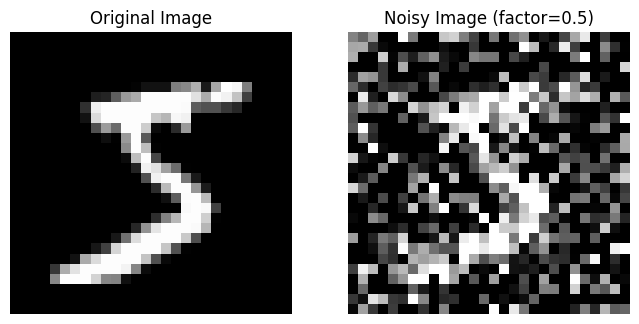

In [23]:
def add_noise(img, noise_factor=0.5):
    noisy_img = img + noise_factor * torch.randn_like(img)
    noisy_img = torch.clamp(noisy_img, 0., 1.)
    return noisy_img

sample_img, _ = train_dataset[0]
noisy_sample = add_noise(sample_img, 0.5)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_img.squeeze(), cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(noisy_sample.squeeze(), cmap='gray')
plt.title('Noisy Image (factor=0.5)')
plt.axis('off')
plt.show()

In [24]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        if decoded.shape[-1] != x.shape[-1]:
            decoded = F.interpolate(decoded, size=x.shape[-2:], mode='bilinear', align_corners=False)
        return decoded

model = DenoisingAutoencoder().to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)
Total parameters: 46,529


In [25]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
noise_factor = 0.5

train_losses = []

In [26]:
print("Training Started...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        noisy_data = add_noise(data, noise_factor)

        outputs = model(noisy_data)
        loss = criterion(outputs, data)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (batch_idx + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}] Average Loss: {epoch_loss:.4f}')

print("Training Completed!")

Training Started...
Epoch [1/10], Step [100/469], Loss: 0.0953
Epoch [1/10], Step [200/469], Loss: 0.0922
Epoch [1/10], Step [300/469], Loss: 0.0858
Epoch [1/10], Step [400/469], Loss: 0.0847
Epoch [1/10] Average Loss: 0.0960
Epoch [2/10], Step [100/469], Loss: 0.0890
Epoch [2/10], Step [200/469], Loss: 0.0776
Epoch [2/10], Step [300/469], Loss: 0.0695
Epoch [2/10], Step [400/469], Loss: 0.0731
Epoch [2/10] Average Loss: 0.0780
Epoch [3/10], Step [100/469], Loss: 0.0761
Epoch [3/10], Step [200/469], Loss: 0.0736
Epoch [3/10], Step [300/469], Loss: 0.0727
Epoch [3/10], Step [400/469], Loss: 0.0751
Epoch [3/10] Average Loss: 0.0732
Epoch [4/10], Step [100/469], Loss: 0.0713
Epoch [4/10], Step [200/469], Loss: 0.0760
Epoch [4/10], Step [300/469], Loss: 0.0689
Epoch [4/10], Step [400/469], Loss: 0.0647
Epoch [4/10] Average Loss: 0.0701
Epoch [5/10], Step [100/469], Loss: 0.0648
Epoch [5/10], Step [200/469], Loss: 0.0667
Epoch [5/10], Step [300/469], Loss: 0.0651
Epoch [5/10], Step [400/469

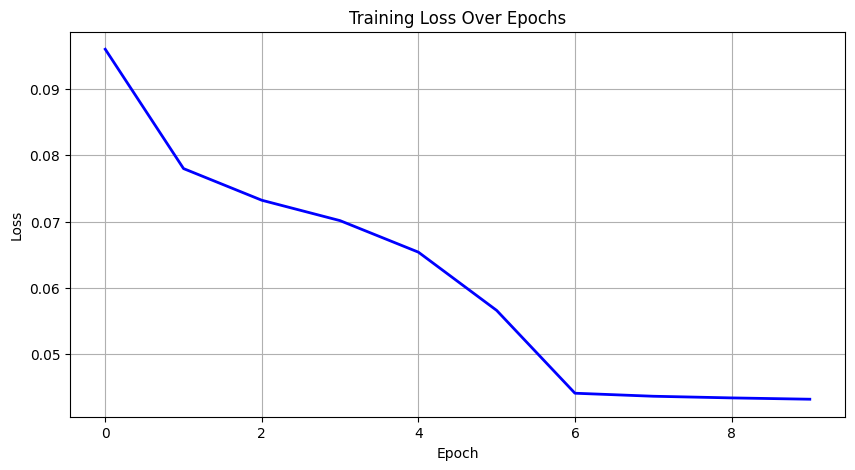

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.show()

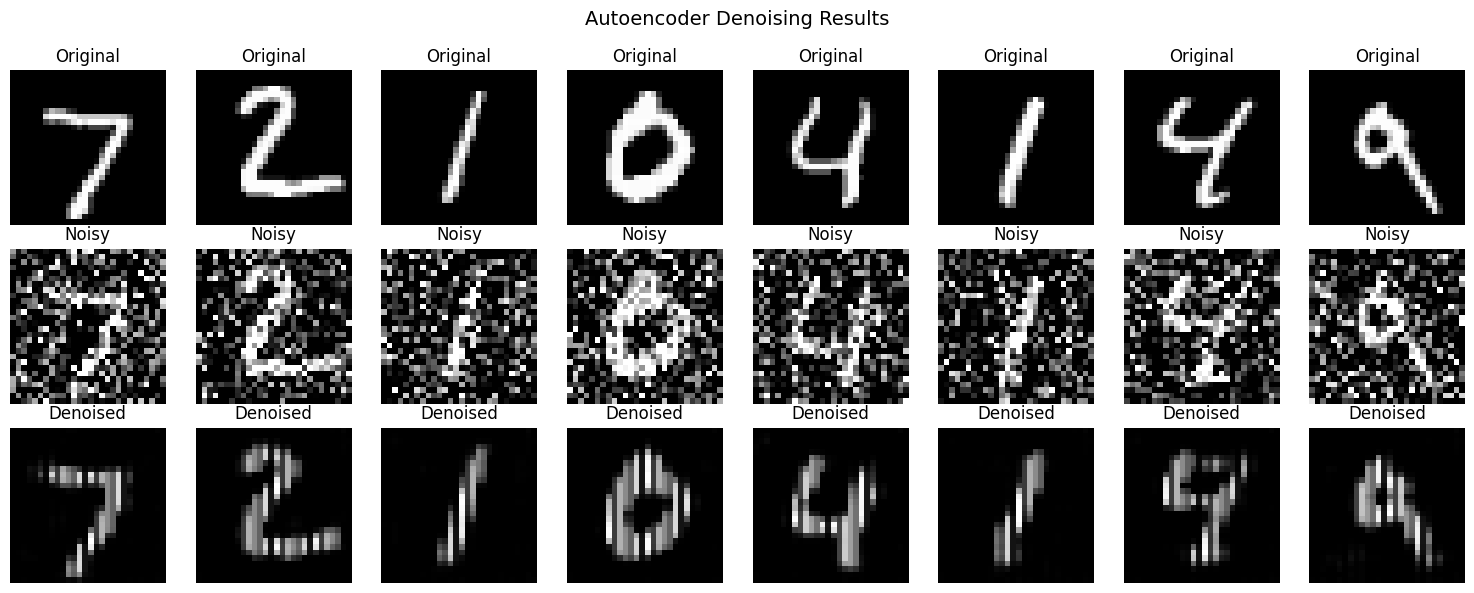

In [28]:
def visualize_results(model, test_loader, num_images=8, noise_factor=0.5):
    model.eval()

    data, _ = next(iter(test_loader))
    data = data[:num_images].to(device)

    noisy_data = add_noise(data, noise_factor)

    with torch.no_grad():
        denoised_data = model(noisy_data)

    data = data.cpu().numpy()
    noisy_data = noisy_data.cpu().numpy()
    denoised_data = denoised_data.cpu().numpy()

    fig, axes = plt.subplots(3, num_images, figsize=(15, 6))

    for i in range(num_images):
        axes[0, i].imshow(data[i].squeeze(), cmap='gray')
        axes[0, i].set_title('Original')
        axes[0, i].axis('off')

        axes[1, i].imshow(noisy_data[i].squeeze(), cmap='gray')
        axes[1, i].set_title('Noisy')
        axes[1, i].axis('off')

        axes[2, i].imshow(denoised_data[i].squeeze(), cmap='gray')
        axes[2, i].set_title('Denoised')
        axes[2, i].axis('off')

    plt.tight_layout()
    plt.suptitle('Autoencoder Denoising Results', fontsize=14)
    plt.subplots_adjust(top=0.88)
    plt.show()

visualize_results(model, test_loader)

In [29]:
# evaluate model

In [30]:
def evaluate_model(model, test_loader, noise_factor=0.5):
    model.eval()
    total_mse = 0.0
    total_psnr = 0.0
    num_samples = 0

    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            noisy_data = add_noise(data, noise_factor)
            denoised_data = model(noisy_data)

            mse = F.mse_loss(denoised_data, data)
            psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))

            total_mse += mse.item() * data.size(0)
            total_psnr += psnr.item() * data.size(0)
            num_samples += data.size(0)

    avg_mse = total_mse / num_samples
    avg_psnr = total_psnr / num_samples

    print(f"Average MSE: {avg_mse:.6f}")
    print(f"Average PSNR: {avg_psnr:.2f} dB")

    return avg_mse, avg_psnr

avg_mse, avg_psnr = evaluate_model(model, test_loader)

Average MSE: 0.043571
Average PSNR: 13.64 dB
